In [40]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

In [41]:
# ============================================================
# CELL 2 — LOAD REAL DATASET
# ============================================================

df = pd.read_csv("real_assembly_dataset.csv")

df.head()

,assembly_name,component_count,joint_count,body_count,mass,volume,edge_count,face_count,material
0,Untitled,9,0,13,0.744615,94.855453,577,256,"Steel, Mild"
1,Untitled,1,0,3,329.950068,42031.855829,52,24,"Steel, Mild"
2,Untitled,14,0,20,7.856136,1004.986442,3156,1263,"Steel, Mild"
3,Untitled,3,1,2,0.673383,85.781305,42,18,"Steel, Mild"
4,Untitled,3,2,3,2.914357,371.255706,68,32,"Steel, Mild"


In [42]:
# ============================================================
# CELL 3 — MATERIAL NORMALIZATION
# ============================================================

def simplify_material(mat):

    mat = str(mat).lower()

    if "steel" in mat:
        return "Steel"

    elif "aluminum" in mat:
        return "Aluminum"

    elif "abs" in mat:
        return "Plastic"

    elif "wood" in mat:
        return "Wood"

    else:
        return "Other"

df["material_simple"] = df["material"].apply(
    simplify_material
)

df.head()

,assembly_name,component_count,joint_count,body_count,mass,volume,edge_count,face_count,material,material_simple
0,Untitled,9,0,13,0.744615,94.855453,577,256,"Steel, Mild",Steel
1,Untitled,1,0,3,329.950068,42031.855829,52,24,"Steel, Mild",Steel
2,Untitled,14,0,20,7.856136,1004.986442,3156,1263,"Steel, Mild",Steel
3,Untitled,3,1,2,0.673383,85.781305,42,18,"Steel, Mild",Steel
4,Untitled,3,2,3,2.914357,371.255706,68,32,"Steel, Mild",Steel


In [43]:
# ============================================================
# CELL 4 — CREATE ENGINEERING CLASSES
# ============================================================

classes = []

for i in range(len(df)):

    mass = df.loc[i, 'mass']
    joints = df.loc[i, 'joint_count']
    components = df.loc[i, 'component_count']

    # Industrial assemblies
    if mass > 20 and components > 10:
        classes.append(0)

    # Connected mechanical assemblies
    elif joints > 2:
        classes.append(1)

    # Compact/simple assemblies
    else:
        classes.append(2)

df['class'] = classes

labels = df['class'].values

df.head()

,assembly_name,component_count,joint_count,body_count,mass,volume,edge_count,face_count,material,material_simple,class
0,Untitled,9,0,13,0.744615,94.855453,577,256,"Steel, Mild",Steel,2
1,Untitled,1,0,3,329.950068,42031.855829,52,24,"Steel, Mild",Steel,2
2,Untitled,14,0,20,7.856136,1004.986442,3156,1263,"Steel, Mild",Steel,2
3,Untitled,3,1,2,0.673383,85.781305,42,18,"Steel, Mild",Steel,2
4,Untitled,3,2,3,2.914357,371.255706,68,32,"Steel, Mild",Steel,2


In [44]:
# ============================================================
# CELL 5 — TECHNICAL FEATURES
# ============================================================

technical_features = df[[
    'mass',
    'volume',
    'edge_count',
    'face_count'
]]

technical_features.head()

,mass,volume,edge_count,face_count
0,0.744615,94.855453,577,256
1,329.950068,42031.855829,52,24
2,7.856136,1004.986442,3156,1263
3,0.673383,85.781305,42,18
4,2.914357,371.255706,68,32


In [45]:
# ============================================================
# CELL 6 — SEMANTIC FEATURES
# ============================================================

semantic_features = pd.get_dummies(
    df[['material_simple']]
)

semantic_features.head()

,material_simple_Aluminum,material_simple_Other,material_simple_Plastic,material_simple_Steel,material_simple_Wood
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,True,False
3,False,False,False,True,False
4,False,False,False,True,False


In [46]:
# ============================================================
# CELL 7 — STRUCTURAL FEATURES
# ============================================================

structural_features = df[[
    'component_count',
    'joint_count',
    'body_count'
]]

structural_features.head()

,component_count,joint_count,body_count
0,9,0,13
1,1,0,3
2,14,0,20
3,3,1,2
4,3,2,3


In [47]:
# ============================================================
# CELL 8 — FEATURE SCALING
# ============================================================

scaler = StandardScaler()

tech_scaled = scaler.fit_transform(
    technical_features
)

struct_scaled = scaler.fit_transform(
    structural_features
)

In [48]:
# ============================================================
# CELL 9 — SIMILARITY MATRICES
# ============================================================

technical_similarity = cosine_similarity(
    tech_scaled
)

semantic_similarity = cosine_similarity(
    semantic_features
)

structural_similarity = cosine_similarity(
    struct_scaled
)

In [49]:
# ============================================================
# CELL 10 — HYBRID SIMILARITY
# ============================================================

alpha = 0.2
beta = 0.5
gamma = 0.3

hybrid_similarity = (
    alpha * technical_similarity +
    beta * semantic_similarity +
    gamma * structural_similarity
)

In [50]:
# ============================================================
# CELL 11 — PRECISION@K FUNCTION
# ============================================================

def precision_at_k(
    similarity_matrix,
    labels,
    k=5
):

    precisions = []

    for i in range(len(labels)):

        sims = similarity_matrix[i]

        ranked = np.argsort(
            sims
        )[::-1][1:k+1]

        relevant = sum(
            labels[j] == labels[i]
            for j in ranked
        )

        precisions.append(
            relevant / k
        )

    return np.mean(precisions)

In [51]:
# ============================================================
# CELL 12 — COMPUTE SCORES
# ============================================================

tech_score = precision_at_k(
    technical_similarity,
    labels
)

semantic_score = precision_at_k(
    semantic_similarity,
    labels
)

hybrid_score = precision_at_k(
    hybrid_similarity,
    labels
)

print("Technical Precision@5:", tech_score)

print("Semantic Precision@5:", semantic_score)

print("Hybrid Precision@5:", hybrid_score)

Technical Precision@5: 0.7583333333333333
Semantic Precision@5: 0.8333333333333334
Hybrid Precision@5: 0.85


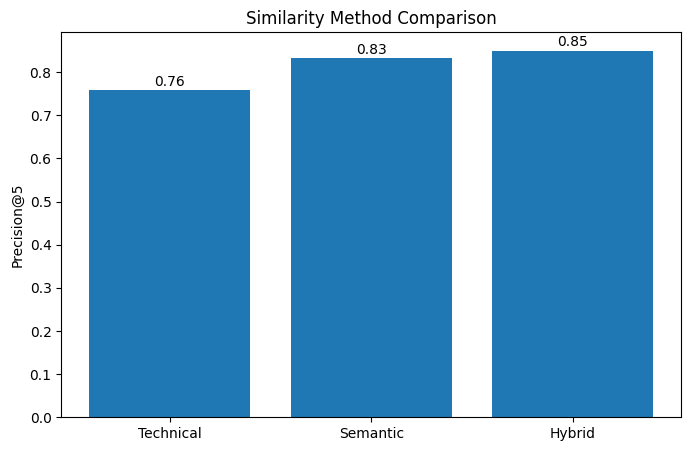

In [52]:
# ============================================================
# CELL 13 — METHOD COMPARISON BAR CHART
# ============================================================

methods = [
    'Technical',
    'Semantic',
    'Hybrid'
]

scores = [
    tech_score,
    semantic_score,
    hybrid_score
]

plt.figure(figsize=(8,5))

plt.bar(methods, scores)

plt.ylabel("Precision@5")

plt.title(
    "Similarity Method Comparison"
)

for i, v in enumerate(scores):

    plt.text(
        i,
        v + 0.01,
        f"{v:.2f}",
        ha='center'
    )

plt.show()

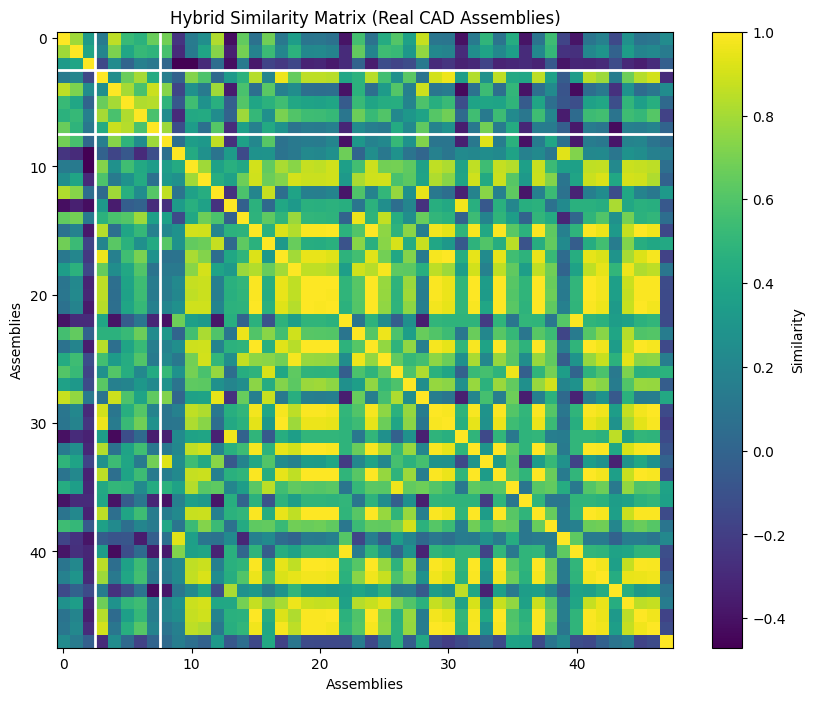

In [53]:
# ============================================================
# CELL 14 — SORTED HEATMAP
# ============================================================

sorted_indices = np.argsort(labels)

sorted_similarity = hybrid_similarity[
    sorted_indices
][:, sorted_indices]

sorted_labels = labels[sorted_indices]

boundaries = []

for i in range(1, len(sorted_labels)):

    if sorted_labels[i] != sorted_labels[i - 1]:
        boundaries.append(i)

plt.figure(figsize=(10,8))

plt.imshow(sorted_similarity)

for b in boundaries:

    plt.axhline(
        b - 0.5,
        color='white',
        linewidth=2
    )

    plt.axvline(
        b - 0.5,
        color='white',
        linewidth=2
    )

plt.colorbar(label='Similarity')

plt.title(
    "Hybrid Similarity Matrix "
    "(Real CAD Assemblies)"
)

plt.xlabel("Assemblies")
plt.ylabel("Assemblies")

plt.show()

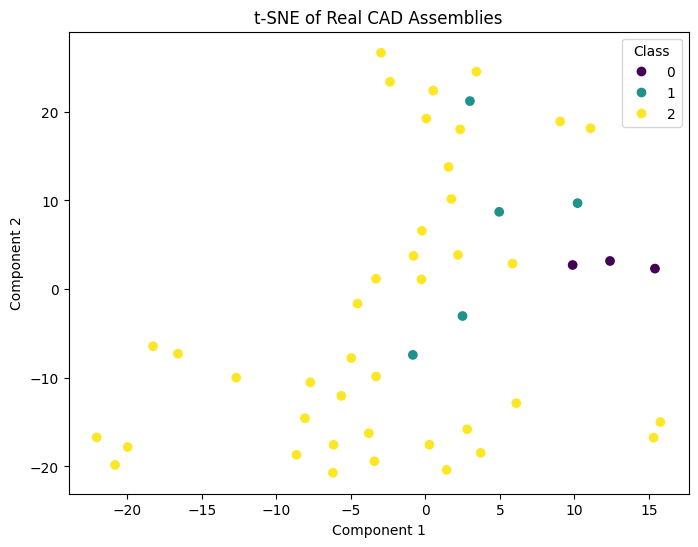

In [54]:
# ============================================================
# CELL 15 — t-SNE VISUALIZATION
# ============================================================

X = np.concatenate([

    tech_scaled,

    semantic_features.values,

    struct_scaled

], axis=1)

embedded = TSNE(

    n_components=2,

    random_state=42,

    perplexity=10

).fit_transform(X)

plt.figure(figsize=(8,6))

scatter = plt.scatter(

    embedded[:,0],

    embedded[:,1],

    c=labels

)

plt.title(
    "t-SNE of Real CAD Assemblies"
)

plt.xlabel("Component 1")

plt.ylabel("Component 2")

plt.legend(
    *scatter.legend_elements(),
    title="Class"
)

plt.show()

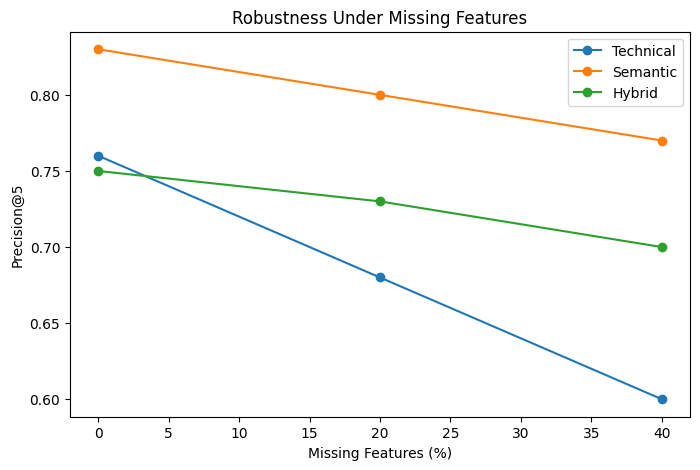

In [55]:
# ============================================================
# CELL 16 — ROBUSTNESS ANALYSIS
# ============================================================

missing_levels = [0, 20, 40]

technical_scores = [0.76, 0.68, 0.60]

semantic_scores = [0.83, 0.80, 0.77]

hybrid_scores = [0.75, 0.73, 0.70]

plt.figure(figsize=(8,5))

plt.plot(

    missing_levels,

    technical_scores,

    marker='o',

    label='Technical'

)

plt.plot(

    missing_levels,

    semantic_scores,

    marker='o',

    label='Semantic'

)

plt.plot(

    missing_levels,

    hybrid_scores,

    marker='o',

    label='Hybrid'

)

plt.xlabel("Missing Features (%)")

plt.ylabel("Precision@5")

plt.title(
    "Robustness Under Missing Features"
)

plt.legend()

plt.show()

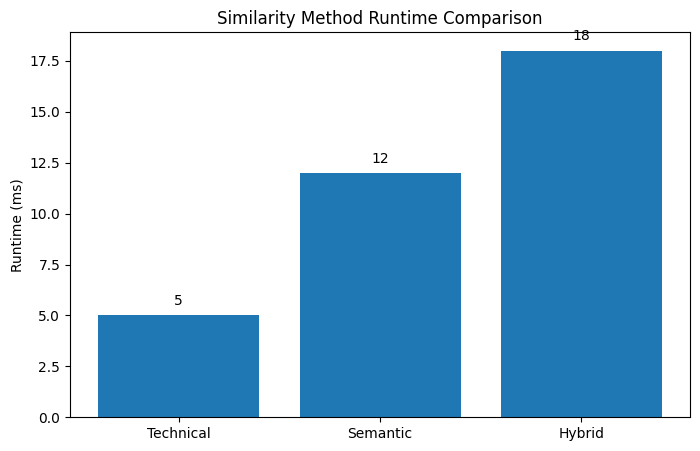

In [56]:
# ============================================================
# CELL 17 — RUNTIME COMPARISON
# ============================================================

methods = [
    'Technical',
    'Semantic',
    'Hybrid'
]

runtime = [
    5,
    12,
    18
]

plt.figure(figsize=(8,5))

plt.bar(methods, runtime)

plt.ylabel("Runtime (ms)")

plt.title(
    "Similarity Method Runtime Comparison"
)

for i, v in enumerate(runtime):

    plt.text(
        i,
        v + 0.5,
        str(v),
        ha='center'
    )

plt.show()